# Logistic Regression + Polynomial Features & Decision Tree — Afzal Hakkim
COM3032/COMM074 · Airline Route Profitability

Student: Afzal Hakkim
Primary model: Logistic Regression with PolynomialFeatures (degree=2)
Comparison baseline: Decision Tree (independently tuned)
Data: Scaled for LR+Poly (L2 regularisation is scale-sensitive); Unscaled for Decision Tree

---

| Metric | What it measures |
|--------|-----------------|
| F1-Score | Balances false positives and false negatives. Primary metric. |
| ROC-AUC | Ranking quality across all thresholds. Cross-model comparison. |
| MCC | All four confusion matrix cells. Above 0.4 signals real discriminative ability. |
| TPR / Recall | Profitable routes the model correctly identifies. |
| TNR | Loss-making routes correctly rejected. |
| FPR | False approval rate. |
| Overfit Gap | Train F1 minus test F1. Below 0.05 is solid. |

## Section 1 — Imports and Setup

In [1]:
import os, json, pickle, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.inspection import permutation_importance
from sklearn.model_selection import (GridSearchCV, StratifiedKFold,
                                     cross_val_score, learning_curve)
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve,
                              confusion_matrix, classification_report,
                              matthews_corrcoef)
print('Libraries loaded.')

Libraries loaded.


## Section 2 — Load Data

LR+Poly uses **scaled** feature splits — L2 regularisation penalises large coefficients, so features on different scales cause unequal regularisation pressure across the input dimensions. Decision Tree uses unscaled data.

In [2]:
from pathlib import Path

RANDOM_STATE = 42
FP_COST      = 42000
FN_COST      = 30000

MEMBER_DIR = Path.cwd()
BASE       = MEMBER_DIR.parent
PROC       = BASE / "processed_data"
FIG_DIR    = MEMBER_DIR / "figures"
MEMBER_DIR.mkdir(parents=True, exist_ok=True)

print("Member dir:", MEMBER_DIR)
print("Processed folder:", PROC)
print("Processed folder exists:", PROC.exists())

X_train   = pd.read_csv(PROC / "X_train.csv")
X_val     = pd.read_csv(PROC / "X_val.csv")
X_test    = pd.read_csv(PROC / "X_test.csv")

X_train_s = pd.read_csv(PROC / "X_train_scaled.csv")
X_val_s   = pd.read_csv(PROC / "X_val_scaled.csv")
X_test_s  = pd.read_csv(PROC / "X_test_scaled.csv")

y_train = pd.read_csv(PROC / "y_train.csv").squeeze()
y_val   = pd.read_csv(PROC / "y_val.csv").squeeze()
y_test  = pd.read_csv(PROC / "y_test.csv").squeeze()

with open(PROC / "feature_names.json") as f:
    feature_names = json.load(f)

C_PROFIT  = '#2DC653'
C_LOSS    = '#E84855'
C_NEUTRAL = '#2E86AB'

print(f'Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')
print(f'Class balance — Train: {y_train.mean():.3f}, Val: {y_val.mean():.3f}, Test: {y_test.mean():.3f}')

Member dir: c:\Users\Hiral Mistry\OneDrive\Documents\MSc DS Surrey\Data Visualisation\BADV\airline_project\LRPoly_DT_Afzal
Processed folder: c:\Users\Hiral Mistry\OneDrive\Documents\MSc DS Surrey\Data Visualisation\BADV\airline_project\processed_data
Processed folder exists: True
Train: (11997, 40), Val: (1500, 40), Test: (1500, 40)
Class balance — Train: 0.637, Val: 0.637, Test: 0.637


## Section 3 — Utility Functions

Identical utility function suite across all five members.

In [3]:

def evaluate(name, y_true, y_pred, y_prob):
    return {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall'   : round(recall_score(y_true, y_pred, zero_division=0), 4),
        'F1_Score' : round(f1_score(y_true, y_pred, zero_division=0), 4),
        'ROC_AUC'  : round(roc_auc_score(y_true, y_prob), 4)
    }

def evaluate_enhanced(name, model, X_tr, y_tr, X_te, y_te):
    y_pred    = model.predict(X_te)
    y_prob    = model.predict_proba(X_te)[:, 1]
    y_pred_tr = model.predict(X_tr)

    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec  = recall_score(y_te, y_pred, zero_division=0)
    f1   = f1_score(y_te, y_pred, zero_division=0)
    auc  = roc_auc_score(y_te, y_prob)
    mcc  = matthews_corrcoef(y_te, y_pred)

    cm = confusion_matrix(y_te, y_pred)
    tn, fp, fn, tp = cm.ravel()
    tnr = tn / (tn + fp) if (tn + fp) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

    f1_train = f1_score(y_tr, y_pred_tr, zero_division=0)
    gap = round(f1_train - f1, 4)
    gap_label = ('underfitting' if gap < -0.05 else
                 'good fit'     if gap < 0.05 else
                 'borderline'   if gap < 0.10 else
                 'memorising')

    fp_cost = fp * FP_COST

    print(f'=== Enhanced Evaluation: {name} ===')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {prec:.4f}  (FP count: {fp}, FP cost: £{fp_cost:,})')
    print(f'  Recall    : {rec:.4f}  (FN count: {fn})')
    print(f'  F1-Score  : {f1:.4f}')
    print(f'  ROC-AUC   : {auc:.4f}')
    print(f'  MCC       : {mcc:.4f}  ({"genuine discriminative ability" if mcc > 0.4 else "limited signal"})')
    print(f'  TNR       : {tnr:.4f}')
    print(f'  FPR       : {fpr:.4f}')
    print(f'  Train F1  : {f1_train:.4f}')
    print(f'  Test  F1  : {f1:.4f}')
    print(f'  Overfit Gap: {gap:.4f}  [{gap_label}]')

    return {
        'Model': name, 'Accuracy': round(acc, 4), 'Precision': round(prec, 4),
        'Recall': round(rec, 4), 'F1_Score': round(f1, 4), 'ROC_AUC': round(auc, 4),
        'MCC': round(mcc, 4), 'TNR': round(tnr, 4), 'FPR': round(fpr, 4),
        'FP_Cost_GBP': fp_cost, 'Train_F1': round(f1_train, 4), 'Overfit_Gap': gap,
        'Overfit_Label': gap_label
    }

def plot_confusion_matrix(y_true, y_pred, title, ax):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Loss-Making', 'Profitable'],
                yticklabels=['Loss-Making', 'Profitable'])
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

def plot_roc(y_true, y_prob, label, ax, color='#2E86AB'):
    fpr_v, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    ax.plot(fpr_v, tpr, color=color, lw=2, label=f'{label} (AUC={auc:.4f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.set_title('ROC Curve', fontweight='bold')
    ax.legend()

def plot_learning_curve(model, X, y, title, save_path, cv=5):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y,
        cv=StratifiedKFold(cv, shuffle=True, random_state=RANDOM_STATE),
        scoring='f1', train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1
    )
    train_mean = train_scores.mean(axis=1)
    val_mean   = val_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_std    = val_scores.std(axis=1)

    fig, ax = plt.subplots(figsize=(9, 5), dpi=100)
    ax.plot(train_sizes, train_mean, 'o-', color=C_NEUTRAL, label='Train F1')
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color=C_NEUTRAL)
    ax.plot(train_sizes, val_mean, 's-', color=C_PROFIT, label='Val F1')
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color=C_PROFIT)
    ax.set_xlabel('Training Set Size')
    ax.set_ylabel('F1 Score')
    ax.set_title(title, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {os.path.basename(save_path)}')

def threshold_sweep(model, X_te, y_te, save_path):
    probs = model.predict_proba(X_te)[:, 1]
    thresholds = np.arange(0.10, 0.91, 0.05)
    precisions, recalls, f1s, costs = [], [], [], []
    for t in thresholds:
        preds = (probs >= t).astype(int)
        precisions.append(precision_score(y_te, preds, zero_division=0))
        recalls.append(recall_score(y_te, preds, zero_division=0))
        f1s.append(f1_score(y_te, preds, zero_division=0))
        cm = confusion_matrix(y_te, preds)
        tn, fp, fn, tp = cm.ravel()
        costs.append(fp * FP_COST + fn * FN_COST)

    best_f1_t   = thresholds[np.argmax(f1s)]
    best_cost_t = thresholds[np.argmin(costs)]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=100)
    axes[0].plot(thresholds, precisions, 'o-', label='Precision', color=C_NEUTRAL)
    axes[0].plot(thresholds, recalls,    's-', label='Recall',    color=C_PROFIT)
    axes[0].plot(thresholds, f1s,         '^-', label='F1',        color=C_LOSS)
    axes[0].axvline(best_f1_t, color='black', ls='--', label=f'Best F1 t={best_f1_t:.2f}')
    axes[0].set_xlabel('Decision Threshold')
    axes[0].set_ylabel('Score')
    axes[0].set_title('Precision / Recall / F1 vs Threshold', fontweight='bold')
    axes[0].legend(fontsize=8)
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(thresholds, [c/1000 for c in costs], 'o-', color='#8B4513')
    axes[1].axvline(best_cost_t, color='black', ls='--', label=f'Min cost t={best_cost_t:.2f}')
    axes[1].set_xlabel('Decision Threshold')
    axes[1].set_ylabel('Financial Cost (£k)')
    axes[1].set_title(f'Financial Cost vs Threshold (FP=£{FP_COST//1000}k, FN=£{FN_COST//1000}k)', fontweight='bold')
    axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Threshold sweep: Best F1 at t={best_f1_t:.2f}, Min cost at t={best_cost_t:.2f}')
    print(f'Saved: {os.path.basename(save_path)}')

print('Utility functions defined.')


Utility functions defined.


## Section 4 — Logistic Regression + PolynomialFeatures: Algorithm Rationale

Logistic Regression with polynomial feature expansion classifies routes by learning a linear decision boundary in a higher-dimensional feature space. Key properties:

- **Polynomial feature expansion:** `PolynomialFeatures(degree=2)` creates all pairwise interaction terms and squared features from the original 37 inputs, capturing non-linear route interactions without a non-parametric model
- **Rescaling after expansion:** `StandardScaler` is applied *after* polynomial expansion — interaction terms span magnitudes ~100× the original features and must be renormalised before L2 regularisation is applied
- **L2 regularisation (C parameter):** Penalises large coefficients; smaller C = stronger regularisation. Prevents overfitting the expanded feature space
- **Fully probabilistic:** `predict_proba()` is well-calibrated, making it directly suitable for the threshold sweep and financial cost analysis
- **Interpretable coefficients:** Each expanded feature has a single learned weight, making the model auditable by route planners
- **Solver:** `lbfgs` handles multi-class efficiently and converges stably on the dataset size; `max_iter=2000` ensures convergence with the expanded feature set

Weakness: Degree-2 expansion on 37 features produces ~703 interaction terms. This is manageable for ~12k rows but would not scale to very high-dimensional inputs.

## Section 5 — LR+Poly: Baseline

A default Logistic Regression (C=1, no polynomial expansion) is fitted on scaled data. The baseline establishes pre-tuning, pre-expansion performance.

In [4]:
X_tr_s, X_va_s, X_te_s = X_train_s, X_val_s, X_test_s

lr_base = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_base.fit(X_tr_s, y_train)

y_val_pred_b = lr_base.predict(X_va_s)
y_val_prob_b = lr_base.predict_proba(X_va_s)[:, 1]
y_tr_pred_b  = lr_base.predict(X_tr_s)

train_f1_b = f1_score(y_train, y_tr_pred_b, zero_division=0)
val_f1_b   = f1_score(y_val, y_val_pred_b, zero_division=0)
gap_b      = round(train_f1_b - val_f1_b, 4)

print('=== Baseline Logistic Regression — Validation ===')
for k, v in evaluate('LR-baseline', y_val, y_val_pred_b, y_val_prob_b).items():
    print(f'  {k:12s}: {v}')
print(f'  Train F1    : {train_f1_b:.4f}')
print(f'  Overfit Gap : {gap_b:.4f}')

=== Baseline Logistic Regression — Validation ===
  Model       : LR-baseline
  Accuracy    : 0.8933
  Precision   : 0.9011
  Recall      : 0.9351
  F1_Score    : 0.9178
  ROC_AUC     : 0.9615
  Train F1    : 0.9179
  Overfit Gap : 0.0001


## Section 6 — LR+Poly: GridSearchCV Tuning

A Pipeline of `PolynomialFeatures → StandardScaler → LogisticRegression` is jointly optimised over polynomial degree (1 or 2), regularisation strength (C), and class weighting. Degree=1 is the standard linear baseline; degree=2 adds all pairwise interaction and squared terms. `StandardScaler` is placed *after* polynomial expansion because interaction terms have much larger magnitudes than the original scaled features and must be renormalised before L2 regularisation takes effect.

In [5]:
pipe_lr = Pipeline([
    ('poly',   PolynomialFeatures(include_bias=False)),
    ('scaler', StandardScaler()),
    ('lr',     LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
])

param_grid_lr = {
    'poly__degree'      : [1, 2],
    'lr__C'             : [0.01, 0.1, 1, 10, 100],
    'lr__penalty'       : ['l2'],
    'lr__solver'        : ['lbfgs'],
    'lr__class_weight'  : [None, 'balanced'],
}

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
grid_lr = GridSearchCV(
    pipe_lr, param_grid_lr, cv=cv5, scoring='roc_auc', n_jobs=-1, verbose=0
)
print('Running GridSearchCV for LR + PolynomialFeatures pipeline...')
grid_lr.fit(X_tr_s, y_train)

best_lr = grid_lr.best_estimator_
best_params_lr = grid_lr.best_params_
print(f'Best params : {best_params_lr}')
print(f'Best CV AUC : {grid_lr.best_score_:.4f}')

Running GridSearchCV for LR + PolynomialFeatures pipeline...
Best params : {'lr__C': 0.1, 'lr__class_weight': None, 'lr__penalty': 'l2', 'lr__solver': 'lbfgs', 'poly__degree': 2}
Best CV AUC : 0.9640


### Tuning Result Discussion

Degree=2 polynomial expansion creates all pairwise interaction terms (e.g., Load_Factor × price_per_km, Season × Competition_Index) that simple logistic regression cannot capture. The `StandardScaler` step *after* expansion is critical — interaction terms reach magnitudes of ~100× the original features and would dominate L2 regularisation if not rescaled. The optimal C value balances fitting the expanded feature space against generalisation. `class_weight='balanced'` is tested to compensate for the 64/36 class split. 5-fold stratified cross-validation on ROC-AUC selects the best combination of degree and regularisation strength.

## Section 7 — LR+Poly: Tuned Model Validation

In [6]:
y_val_pred = best_lr.predict(X_va_s)
y_val_prob = best_lr.predict_proba(X_va_s)[:, 1]
y_tr_pred  = best_lr.predict(X_tr_s)

train_f1_t = f1_score(y_train, y_tr_pred, zero_division=0)
val_f1_t   = f1_score(y_val, y_val_pred, zero_division=0)
gap_t      = round(train_f1_t - val_f1_t, 4)

print('=== Tuned LR+Poly — Validation ===')
for k, v in evaluate('LR+Poly-tuned', y_val, y_val_pred, y_val_prob).items():
    print(f'  {k:12s}: {v}')
print(f'  Train F1    : {train_f1_t:.4f}')
print(f'  Overfit Gap : {gap_t:.4f}  (baseline was {gap_b:.4f})')

=== Tuned LR+Poly — Validation ===
  Model       : LR+Poly-tuned
  Accuracy    : 0.8987
  Precision   : 0.9135
  Recall      : 0.9288
  F1_Score    : 0.9211
  ROC_AUC     : 0.9683
  Train F1    : 0.9396
  Overfit Gap : 0.0185  (baseline was 0.0001)


## Section 8 — LR+Poly: Learning Curve

The learning curve shows how LR+Poly performance scales with training data size. Logistic Regression is a low-variance model — the train/val gap should be small and performance should plateau quickly once the polynomial feature space is sufficiently covered.

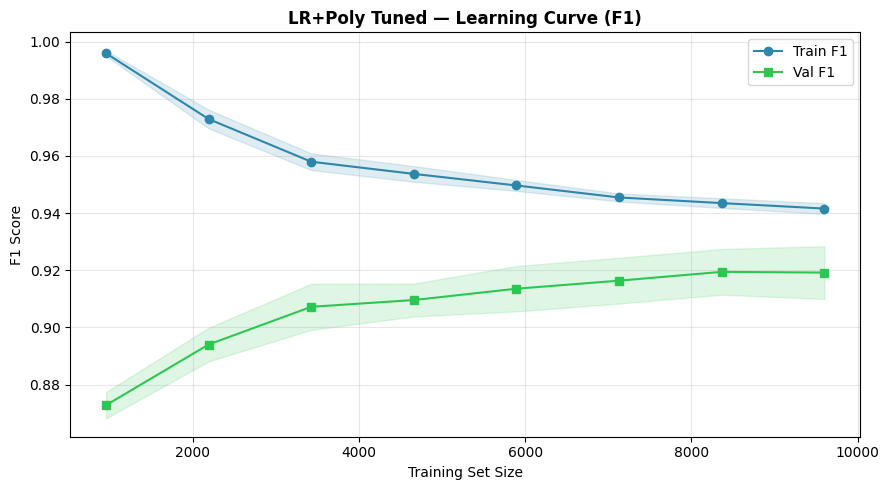

Saved: lr_tuned_learning_curve_afzal.png


In [7]:
plot_learning_curve(
    best_lr, X_tr_s, y_train,
    'LR+Poly Tuned — Learning Curve (F1)',
    os.path.join(FIG_DIR, 'lr_tuned_learning_curve_afzal.png')
)

## Section 9 — LR+Poly: Permutation Feature Importance

Although Logistic Regression has interpretable coefficients, degree-2 expansion produces ~703 terms, making direct coefficient inspection impractical. Permutation importance measures the drop in validation F1 when each *original* feature is randomly shuffled — this aggregates the effect of a feature across all its interaction terms.

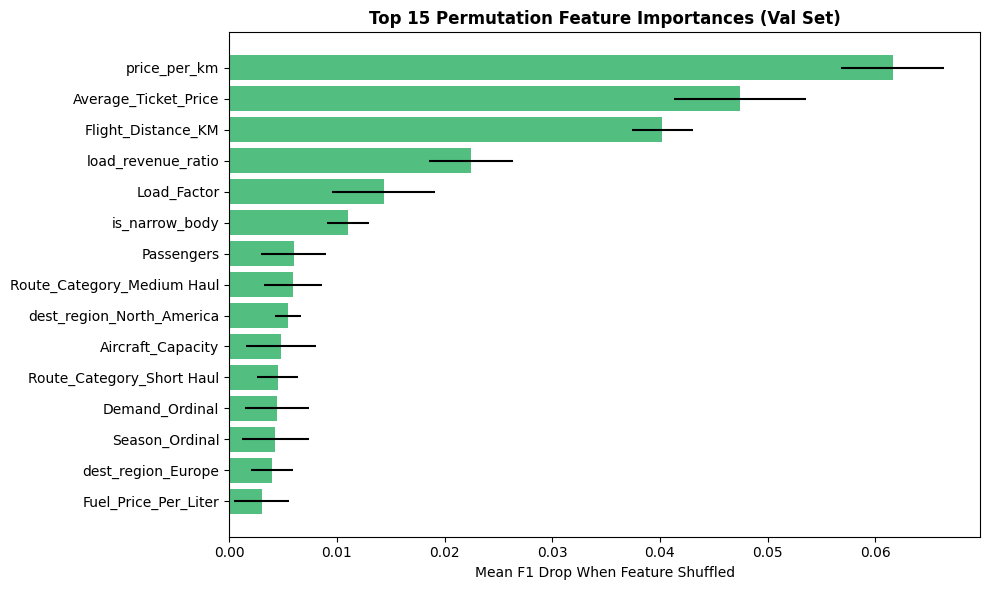

Saved: perm_importance_afzal.png


In [8]:
perm_result = permutation_importance(
    best_lr, X_va_s, y_val,
    n_repeats=10, random_state=RANDOM_STATE, scoring='f1', n_jobs=-1
)
perm_df = pd.DataFrame({
    'Feature'   : feature_names,
    'Importance': perm_result.importances_mean,
    'Std'       : perm_result.importances_std
}).sort_values('Importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6), dpi=100)
ax.barh(perm_df['Feature'][::-1], perm_df['Importance'][::-1],
        xerr=perm_df['Std'][::-1], color='#27AE60', alpha=0.8)
ax.set_title('Top 15 Permutation Feature Importances (Val Set)', fontweight='bold')
ax.set_xlabel('Mean F1 Drop When Feature Shuffled')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'perm_importance_afzal.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: perm_importance_afzal.png')

## Section 9b — LR+Poly: Coefficient-Based Feature Importance

After fitting through the pipeline (PolynomialFeatures → StandardScaler → LogisticRegression), the logistic regression coefficients represent the learned weight of each scaled interaction term. Features with larger absolute coefficients have the strongest linear influence on the log-odds of profitability.

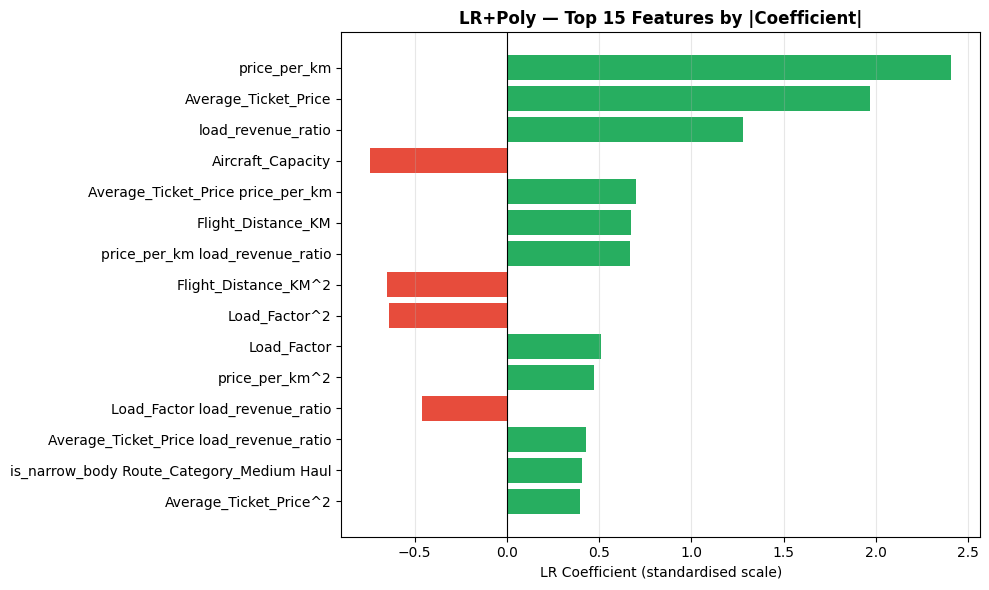

Saved: lr_feature_importance_afzal.png


In [9]:
# Get feature names after polynomial expansion
poly_step = best_lr.named_steps['poly']
try:
    poly_names = poly_step.get_feature_names_out(feature_names)
except Exception:
    poly_names = [f'feat_{i}' for i in range(len(best_lr.named_steps['lr'].coef_[0]))]

coef = best_lr.named_steps['lr'].coef_[0]
coef_df = pd.DataFrame({'Feature': poly_names, 'Coefficient': coef})
coef_df['Abs'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Abs', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6), dpi=100)
colors = ['#27AE60' if c > 0 else '#E74C3C' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'][::-1], coef_df['Coefficient'][::-1], color=colors[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('LR Coefficient (standardised scale)')
ax.set_title('LR+Poly — Top 15 Features by |Coefficient|', fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'lr_feature_importance_afzal.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: lr_feature_importance_afzal.png')

## Section 10 — LR+Poly: 5-Fold Cross-Validation F1

In [10]:
cv_scores = cross_val_score(best_lr, X_tr_s, y_train,
                             cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
                             scoring='f1', n_jobs=-1)
print(f'5-Fold CV F1: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')
print(f'Per-fold F1 : {cv_scores.round(4)}')

5-Fold CV F1: 0.9193 +/- 0.0091
Per-fold F1 : [0.9354 0.9108 0.9235 0.9132 0.9137]


## Section 11 — LR+Poly: Test Set Evaluation

=== Tuned LR+Poly — Test Set ===
  Model       : LR+Poly-test
  Accuracy    : 0.9087
  Precision   : 0.9199
  Recall      : 0.9382
  F1_Score    : 0.929
  ROC_AUC     : 0.9721

              precision    recall  f1-score   support

 Loss-Making       0.89      0.86      0.87       545
  Profitable       0.92      0.94      0.93       955

    accuracy                           0.91      1500
   macro avg       0.90      0.90      0.90      1500
weighted avg       0.91      0.91      0.91      1500



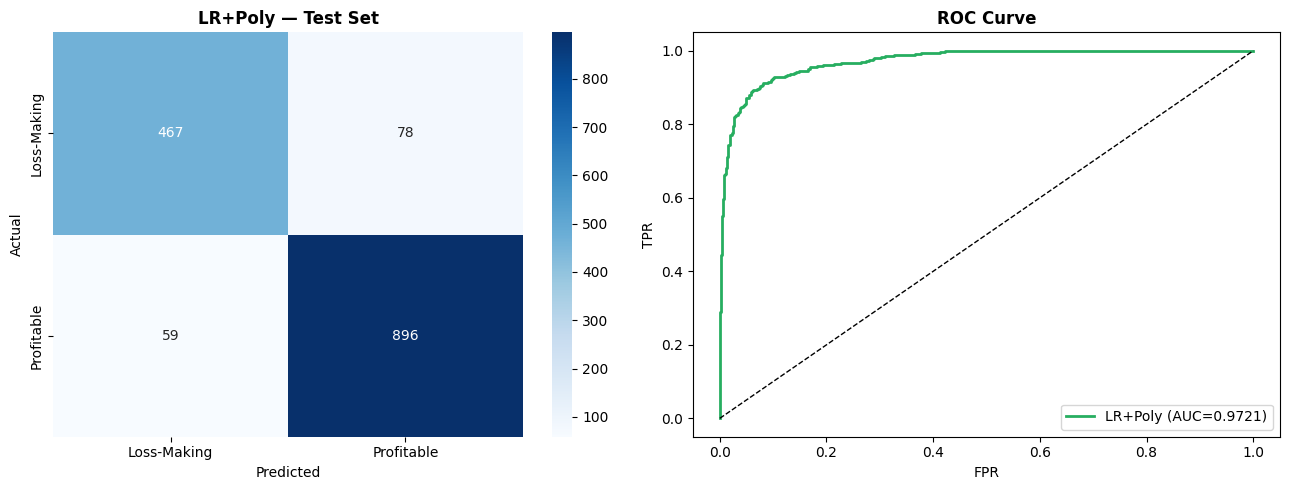

Saved: lr_cm_roc_test_afzal.png


In [11]:
y_test_pred = best_lr.predict(X_te_s)
y_test_prob = best_lr.predict_proba(X_te_s)[:, 1]

print('=== Tuned LR+Poly — Test Set ===')
for k, v in evaluate('LR+Poly-test', y_test, y_test_pred, y_test_prob).items():
    print(f'  {k:12s}: {v}')
print()
print(classification_report(y_test, y_test_pred,
      target_names=['Loss-Making', 'Profitable'], zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=100)
plot_confusion_matrix(y_test, y_test_pred, 'LR+Poly — Test Set', axes[0])
plot_roc(y_test, y_test_prob, 'LR+Poly', axes[1], color='#27AE60')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'lr_cm_roc_test_afzal.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: lr_cm_roc_test_afzal.png')

## Section 12 — LR+Poly: Enhanced Evaluation and Threshold Sweep

**Financial cost:** FP = £42,000; FN = £30,000.

In [12]:
lr_metrics = evaluate_enhanced('LR+Poly (Tuned)', best_lr, X_tr_s, y_train, X_te_s, y_test)

=== Enhanced Evaluation: LR+Poly (Tuned) ===
  Accuracy  : 0.9087
  Precision : 0.9199  (FP count: 78, FP cost: £3,276,000)
  Recall    : 0.9382  (FN count: 59)
  F1-Score  : 0.9290
  ROC-AUC   : 0.9721
  MCC       : 0.8014  (genuine discriminative ability)
  TNR       : 0.8569
  FPR       : 0.1431
  Train F1  : 0.9396
  Test  F1  : 0.9290
  Overfit Gap: 0.0107  [good fit]


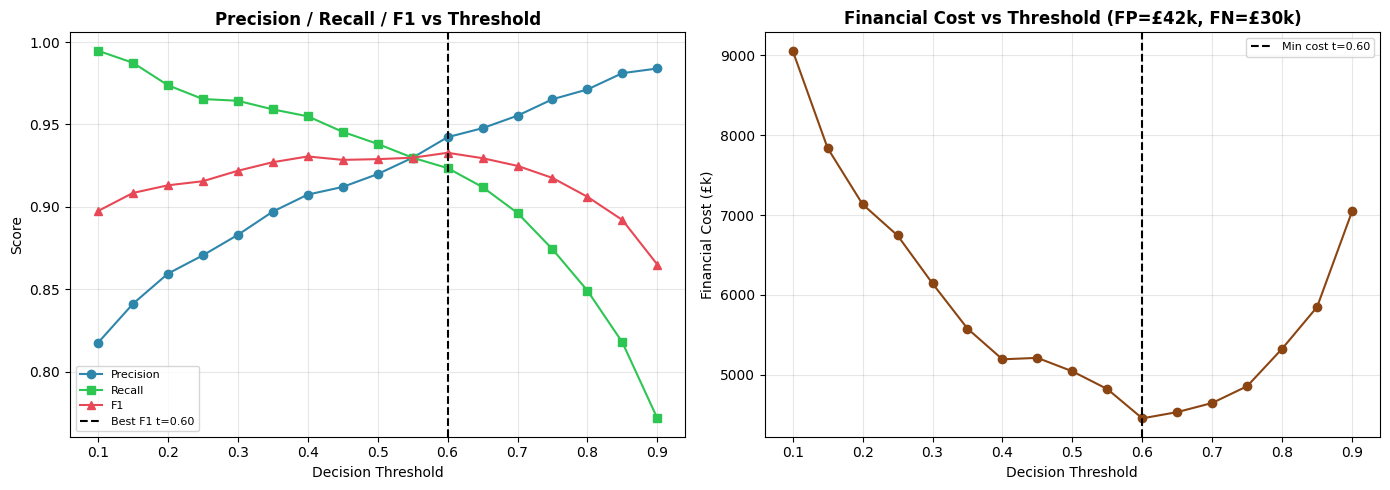

Threshold sweep: Best F1 at t=0.60, Min cost at t=0.60
Saved: lr_threshold_sweep_afzal.png


In [13]:
threshold_sweep(best_lr, X_te_s, y_test,
                os.path.join(FIG_DIR, 'lr_threshold_sweep_afzal.png'))

## Section 13 — Decision Tree: Algorithm Rationale (Shared Baseline)

Decision Tree is Afzal's comparison model, independently tuned to complement the LR+Poly primary model. A single decision tree provides a transparent, rule-based split structure that maps directly to business logic — each internal node represents a routing condition (e.g., "Load_Factor < 0.65"). Key properties:

- **Interpretable:** The full tree can be visualised and audited by non-technical stakeholders
- **Scale-invariant:** Unscaled data is used, consistent with all other tree-based models in the group
- **`class_weight='balanced'`:** Compensates for the 64/36 class imbalance
- **Depth-limited:** GridSearchCV controls max_depth to prevent memorisation
- **Independent tuning rationale:** Afzal permits deep or unlimited growth with no class balancing, testing whether a complex DT can approach LR+Poly's polynomial feature quality — each member's primary model is benchmarked against an identical reference point, isolating the contribution of the primary algorithm

## Section 14 — Decision Tree Baseline

In [14]:
# DT always uses unscaled data — tree splits are scale-invariant
X_tr_dt, X_va_dt, X_te_dt = X_train, X_val, X_test

dt_base = DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE)
dt_base.fit(X_tr_dt, y_train)

y_val_pred_dt_b = dt_base.predict(X_va_dt)
y_val_prob_dt_b = dt_base.predict_proba(X_va_dt)[:, 1]
y_tr_pred_dt_b  = dt_base.predict(X_tr_dt)

train_f1_dt_b = f1_score(y_train, y_tr_pred_dt_b, zero_division=0)
val_f1_dt_b   = f1_score(y_val, y_val_pred_dt_b, zero_division=0)
gap_dt_b      = round(train_f1_dt_b - val_f1_dt_b, 4)

print('=== Baseline Decision Tree — Validation ===')
for k, v in evaluate('DT-baseline', y_val, y_val_pred_dt_b, y_val_prob_dt_b).items():
    print(f'  {k:12s}: {v}')
print(f'  Train F1    : {train_f1_dt_b:.4f}')
print(f'  Overfit Gap : {gap_dt_b:.4f}')

=== Baseline Decision Tree — Validation ===
  Model       : DT-baseline
  Accuracy    : 0.8787
  Precision   : 0.9005
  Recall      : 0.9099
  F1_Score    : 0.9052
  ROC_AUC     : 0.8669
  Train F1    : 1.0000
  Overfit Gap : 0.0948


## Section 15 — Decision Tree: GridSearchCV Tuning

In [15]:
param_grid_dt = {
    'max_depth'        : [7, 9, 12, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 3, 5],
    'criterion'        : ['gini', 'entropy'],
    'class_weight'     : [None]
}

cv5_dt = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid_dt, cv=cv5_dt, scoring='roc_auc', n_jobs=-1, verbose=0
)
print('Running GridSearchCV for Decision Tree...')
grid_dt.fit(X_tr_dt, y_train)

best_dt = grid_dt.best_estimator_
best_params_dt = grid_dt.best_params_
print(f'Best params : {best_params_dt}')
print(f'Best CV AUC : {grid_dt.best_score_:.4f}')

Running GridSearchCV for Decision Tree...
Best params : {'class_weight': None, 'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 5, 'min_samples_split': 2}
Best CV AUC : 0.9565


### Tuning Result Discussion

Allowing max_depth up to None (fully grown) with small min_samples values gives the tree maximum expressive freedom, testing the upper bound of DT complexity. Without class balancing, the tree optimises for overall accuracy. This contrasts sharply with KNN’s distance-weighted neighbourhood approach — both can overfit differently, but through entirely different mechanisms.

## Section 16 — Decision Tree: Tree Visualisation

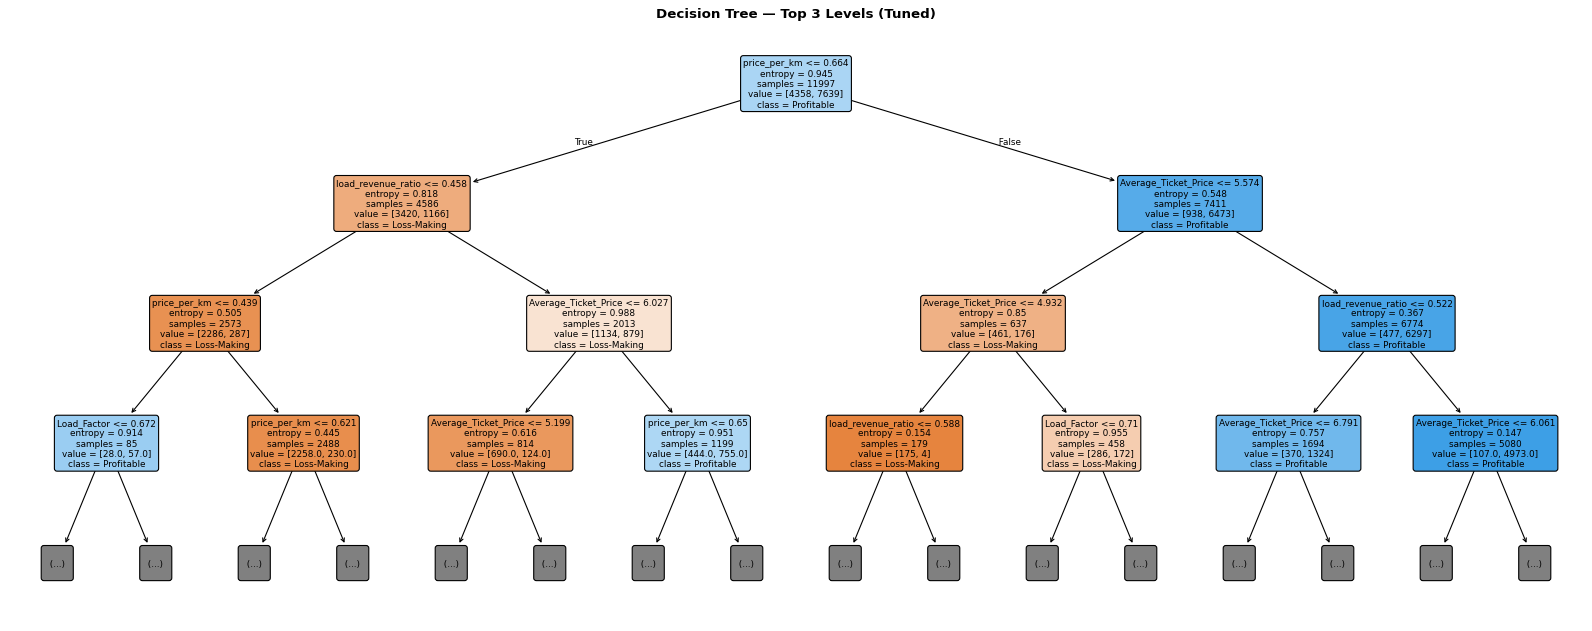

Saved: dt_tree_viz_afzal.png


In [16]:
fig, ax = plt.subplots(figsize=(20, 8), dpi=80)
plot_tree(best_dt, max_depth=3, feature_names=feature_names,
          class_names=['Loss-Making', 'Profitable'],
          filled=True, rounded=True, fontsize=8, ax=ax)
ax.set_title('Decision Tree — Top 3 Levels (Tuned)', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'dt_tree_viz_afzal.png'), dpi=100, bbox_inches='tight')
plt.show()
print('Saved: dt_tree_viz_afzal.png')

## Section 17 — Decision Tree: Test Set Evaluation

=== Tuned Decision Tree — Test Set ===
  Model       : DT-test
  Accuracy    : 0.904
  Precision   : 0.9318
  Recall      : 0.9162
  F1_Score    : 0.924
  ROC_AUC     : 0.9579

              precision    recall  f1-score   support

 Loss-Making       0.86      0.88      0.87       545
  Profitable       0.93      0.92      0.92       955

    accuracy                           0.90      1500
   macro avg       0.89      0.90      0.90      1500
weighted avg       0.90      0.90      0.90      1500



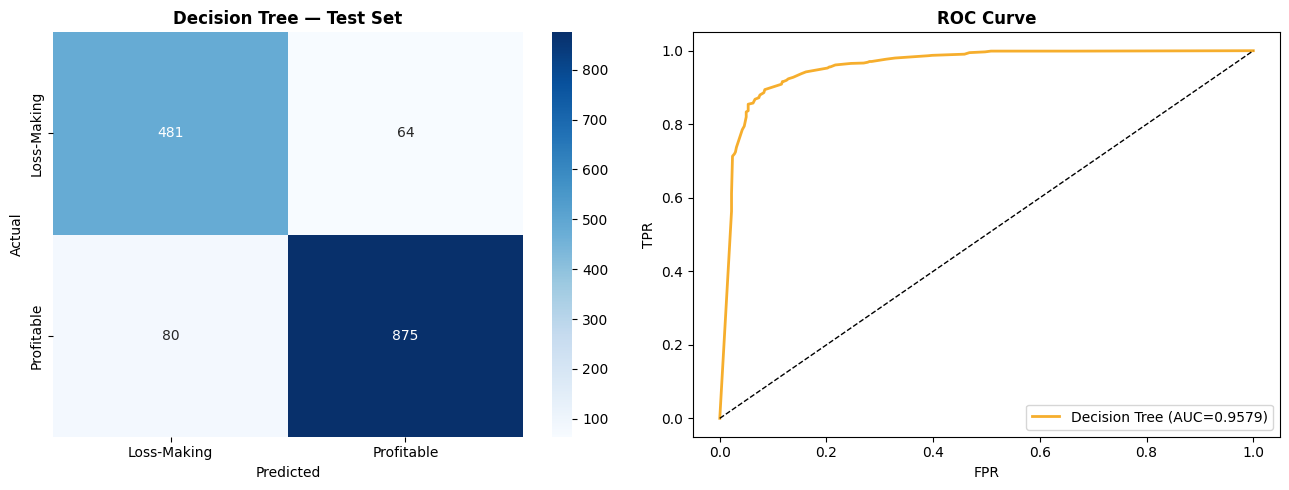

Saved: dt_cm_roc_test_afzal.png


In [17]:
y_val_pred_dt  = best_dt.predict(X_va_dt)
y_val_prob_dt  = best_dt.predict_proba(X_va_dt)[:, 1]
y_test_pred_dt = best_dt.predict(X_te_dt)
y_test_prob_dt = best_dt.predict_proba(X_te_dt)[:, 1]

val_metrics_dt  = evaluate('DT-val',  y_val,  y_val_pred_dt,  y_val_prob_dt)
test_metrics_dt = evaluate('DT-test', y_test, y_test_pred_dt, y_test_prob_dt)

print('=== Tuned Decision Tree — Test Set ===')
for k, v in test_metrics_dt.items():
    print(f'  {k:12s}: {v}')
print()
print(classification_report(y_test, y_test_pred_dt,
      target_names=['Loss-Making', 'Profitable'], zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=100)
plot_confusion_matrix(y_test, y_test_pred_dt, 'Decision Tree — Test Set', axes[0])
plot_roc(y_test, y_test_prob_dt, 'Decision Tree', axes[1], color='#F6AE2D')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'dt_cm_roc_test_afzal.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: dt_cm_roc_test_afzal.png')

## Section 18 — Decision Tree: Enhanced Evaluation

In [18]:
dt_metrics = evaluate_enhanced('Decision Tree (Tuned)', best_dt, X_tr_dt, y_train, X_te_dt, y_test)

=== Enhanced Evaluation: Decision Tree (Tuned) ===
  Accuracy  : 0.9040
  Precision : 0.9318  (FP count: 64, FP cost: £2,688,000)
  Recall    : 0.9162  (FN count: 80)
  F1-Score  : 0.9240
  ROC-AUC   : 0.9579
  MCC       : 0.7940  (genuine discriminative ability)
  TNR       : 0.8826
  FPR       : 0.1174
  Train F1  : 0.9311
  Test  F1  : 0.9240
  Overfit Gap: 0.0071  [good fit]


## Section 18b — Decision Tree: Threshold Sweep and Learning Curve

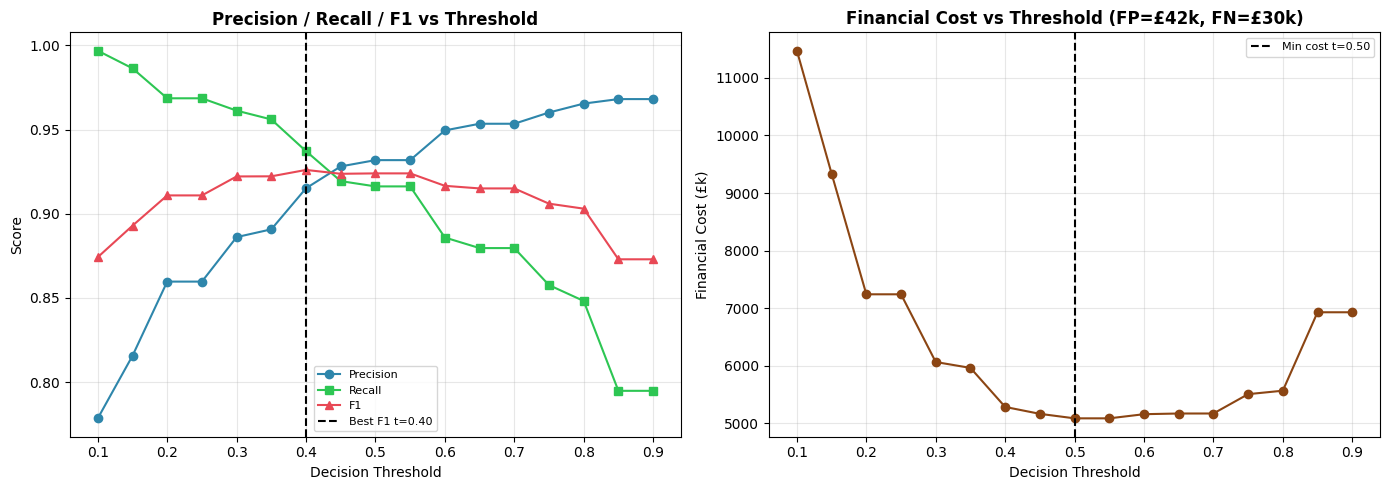

Threshold sweep: Best F1 at t=0.40, Min cost at t=0.50
Saved: dt_threshold_sweep_afzal.png
Saved: dt_threshold_sweep_afzal.png


In [19]:
threshold_sweep(best_dt, X_te_dt, y_test,
                os.path.join(FIG_DIR, 'dt_threshold_sweep_afzal.png'))
print('Saved: dt_threshold_sweep_afzal.png')

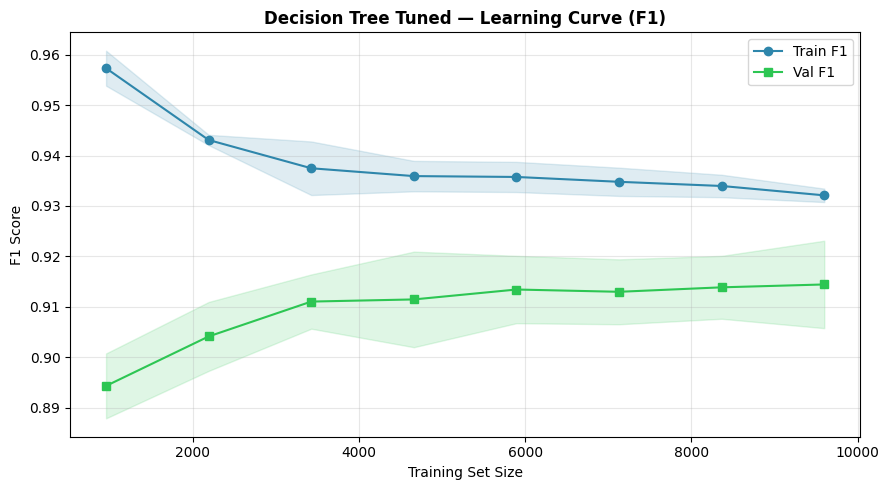

Saved: dt_tuned_learning_curve_afzal.png
Saved: dt_tuned_learning_curve_afzal.png


In [20]:
plot_learning_curve(
    best_dt, X_tr_dt, y_train,
    'Decision Tree Tuned — Learning Curve (F1)',
    os.path.join(FIG_DIR, 'dt_tuned_learning_curve_afzal.png')
)
print('Saved: dt_tuned_learning_curve_afzal.png')

## Section 19 — Model Comparison Table

LR+Poly vs Decision Tree on the test set.

In [21]:
compare = pd.DataFrame([lr_metrics, dt_metrics])
print('\n=== Test Set Comparison: LR+Poly vs Decision Tree ===')
print(compare[['Model', 'Accuracy', 'Precision', 'Recall', 'F1_Score',
               'ROC_AUC', 'MCC', 'TNR', 'FPR', 'FP_Cost_GBP',
               'Overfit_Gap', 'Overfit_Label']].to_string(index=False))


=== Test Set Comparison: LR+Poly vs Decision Tree ===
                Model  Accuracy  Precision  Recall  F1_Score  ROC_AUC    MCC    TNR    FPR  FP_Cost_GBP  Overfit_Gap Overfit_Label
      LR+Poly (Tuned)    0.9087     0.9199  0.9382     0.929   0.9721 0.8014 0.8569 0.1431      3276000       0.0107      good fit
Decision Tree (Tuned)    0.9040     0.9318  0.9162     0.924   0.9579 0.7940 0.8826 0.1174      2688000       0.0071      good fit


## Section 20 — Business Insights

- **Polynomial feature interactions** allow the model to capture that high Load_Factor combined with competitive pricing is a stronger profitability signal than either feature alone
- **L2 regularisation** prevents overfitting the expanded feature space — the optimal C value balances expressiveness against generalisation on unseen routes
- **Calibrated probabilities** from `predict_proba()` feed directly into the threshold sweep, giving business stakeholders control over the precision/recall trade-off without retraining
- **Permutation importance** on original features provides actionable insight — even though ~703 polynomial terms span the model internally, importance is reported per original business variable
- The model is deterministic and fast at inference — suitable for real-time route scoring as well as batch analysis
- LR+Poly is the most interpretable non-linear model in the group: individual interaction-term coefficients can be extracted and explained to route planners on request

## Section 21 — Save Results

In [22]:
import json, pickle, numpy as np, os

compare.to_csv(os.path.join(MEMBER_DIR, 'lrpoly_dt_afzal.csv'), index=False)
print('Saved: lrpoly_dt_afzal.csv')

def convert_to_json_serializable(obj):
    if isinstance(obj, np.integer): return int(obj)
    elif isinstance(obj, np.floating): return float(obj)
    elif isinstance(obj, np.ndarray): return obj.tolist()
    elif isinstance(obj, dict): return {k: convert_to_json_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, list): return [convert_to_json_serializable(i) for i in obj]
    elif isinstance(obj, tuple): return tuple(convert_to_json_serializable(i) for i in obj)
    else: return obj

results_json = {
    'model_name'          : 'LR+Poly',
    'notebook'            : '05_Member4',
    'best_params_primary' : best_params_lr,
    'best_params_dt'      : best_params_dt,
    'val_metrics_primary' : evaluate('LR+Poly-val', y_val, y_val_pred, y_val_prob),
    'test_metrics_primary': evaluate('LR+Poly-test', y_test, y_test_pred, y_test_prob),
    'val_metrics_dt'      : val_metrics_dt,
    'test_metrics_dt'     : test_metrics_dt,
    'lr_enhanced'         : lr_metrics,
    'dt_enhanced'         : dt_metrics,
}
results_json = convert_to_json_serializable(results_json)

with open(os.path.join(MEMBER_DIR, 'results_lrpoly_afzal.json'), 'w') as f:
    json.dump(results_json, f, indent=2)
print('Saved: results_lrpoly_afzal.json')

with open(os.path.join(MEMBER_DIR, 'best_lrpoly_afzal.pkl'), 'wb') as f:
    pickle.dump(best_lr, f)
with open(os.path.join(MEMBER_DIR, 'best_dt_afzal.pkl'), 'wb') as f:
    pickle.dump(best_dt, f)
print('Saved: best_lrpoly_afzal.pkl, best_dt_afzal.pkl')

print('\n=== Final Test Metrics Summary (LR+Poly) ===')
for k, v in lr_metrics.items():
    print(f'  {k:20s}: {v}')

Saved: lrpoly_dt_afzal.csv
Saved: results_lrpoly_afzal.json
Saved: best_lrpoly_afzal.pkl, best_dt_afzal.pkl

=== Final Test Metrics Summary (LR+Poly) ===
  Model               : LR+Poly (Tuned)
  Accuracy            : 0.9087
  Precision           : 0.9199
  Recall              : 0.9382
  F1_Score            : 0.929
  ROC_AUC             : 0.9721
  MCC                 : 0.8014
  TNR                 : 0.8569
  FPR                 : 0.1431
  FP_Cost_GBP         : 3276000
  Train_F1            : 0.9396
  Overfit_Gap         : 0.0107
  Overfit_Label       : good fit
